# ExtraaLearn Project

## Context

The EdTech industry has been surging in the past decade immensely, and according to a forecast, the Online Education market would be worth $286.62bn by 2023 with a compound annual growth rate (CAGR) of 10.26% from 2018 to 2023. The modern era of online education has enforced a lot in its growth and expansion beyond any limit. Due to having many dominant features like ease of information sharing, personalized learning experience, transparency of assessment, etc, it is now preferable to traditional education.

In the present scenario due to the Covid-19, the online education sector has witnessed rapid growth and is attracting a lot of new customers. Due to this rapid growth, many new companies have emerged in this industry. With the availability and ease of use of digital marketing resources, companies can reach out to a wider audience with their offerings. The customers who show interest in these offerings are termed as leads. There are various sources of obtaining leads for Edtech companies, like

* The customer interacts with the marketing front on social media or other online platforms.
* The customer browses the website/app and downloads the brochure
* The customer connects through emails for more information.

The company then nurtures these leads and tries to convert them to paid customers. For this, the representative from the organization connects with the lead on call or through email to share further details.

## Objective

ExtraaLearn is an initial stage startup that offers programs on cutting-edge technologies to students and professionals to help them upskill/reskill. With a large number of leads being generated on a regular basis, one of the issues faced by ExtraaLearn is to identify which of the leads are more likely to convert so that they can allocate resources accordingly. You, as a data scientist at ExtraaLearn, have been provided the leads data to:
* Analyze and build an ML model to help identify which leads are more likely to convert to paid customers,
* Find the factors driving the lead conversion process
* Create a profile of the leads which are likely to convert


## Data Description

The data contains the different attributes of leads and their interaction details with ExtraaLearn. The detailed data dictionary is given below.


**Data Dictionary**
* ID: ID of the lead
* age: Age of the lead
* current_occupation: Current occupation of the lead. Values include 'Professional','Unemployed',and 'Student'
* first_interaction: How did the lead first interacted with ExtraaLearn. Values include 'Website', 'Mobile App'
* profile_completed: What percentage of profile has been filled by the lead on the website/mobile app. Values include Low - (0-50%), Medium - (50-75%), High (75-100%)
* website_visits: How many times has a lead visited the website
* time_spent_on_website: Total time spent on the website
* page_views_per_visit: Average number of pages on the website viewed during the visits.
* last_activity: Last interaction between the lead and ExtraaLearn.
    * Email Activity: Seeking for details about program through email, Representative shared information with lead like brochure of program , etc
    * Phone Activity: Had a Phone Conversation with representative, Had conversation over SMS with representative, etc
    * Website Activity: Interacted on live chat with representative, Updated profile on website, etc

* print_media_type1: Flag indicating whether the lead had seen the ad of ExtraaLearn in the Newspaper.
* print_media_type2: Flag indicating whether the lead had seen the ad of ExtraaLearn in the Magazine.
* digital_media: Flag indicating whether the lead had seen the ad of ExtraaLearn on the digital platforms.
* educational_channels: Flag indicating whether the lead had heard about ExtraaLearn in the education channels like online forums, discussion threads, educational websites, etc.
* referral: Flag indicating whether the lead had heard about ExtraaLearn through reference.
* status: Flag indicating whether the lead was converted to a paid customer or not.

## Importing necessary libraries and data

In [59]:
import warnings

warnings.filterwarnings("ignore")
from statsmodels.tools.sm_exceptions import ConvergenceWarning

warnings.simplefilter("ignore", ConvergenceWarning)

# Libraries to help with reading and manipulating data

import pandas as pd
import numpy as np

# Library to split data
from sklearn.model_selection import train_test_split

# libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 200)
# setting the precision of floating numbers to 5 decimal points
pd.set_option("display.float_format", lambda x: "%.5f" % x)

# To build model for prediction
import statsmodels.stats.api as sms
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
from statsmodels.tools.tools import add_constant
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.ensemble import RandomForestClassifier

# To tune different models
from sklearn.model_selection import GridSearchCV


# To get diferent metric scores
import sklearn.metrics as metrics
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    precision_recall_curve,
    roc_curve,
    make_scorer,
)

In [60]:
#import data

data = pd.read_csv("/content/ExtraaLearn.csv")


In [61]:
#view first 5 rows

data.head()

,ID,age,current_occupation,first_interaction,profile_completed,website_visits,time_spent_on_website,page_views_per_visit,last_activity,print_media_type1,print_media_type2,digital_media,educational_channels,referral,status
0,EXT001,57,Unemployed,Website,High,7,1639,1.86100,Website Activity,Yes,No,Yes,No,No,1
1,EXT002,56,Professional,Mobile App,Medium,2,83,0.32000,Website Activity,No,No,No,Yes,No,0
2,EXT003,52,Professional,Website,Medium,3,330,0.07400,Website Activity,No,No,Yes,No,No,0
3,EXT004,53,Unemployed,Website,High,4,464,2.05700,Website Activity,No,No,No,No,No,1
4,EXT005,23,Student,Website,High,4,600,16.91400,Email Activity,No,No,No,No,No,0


In [62]:
#last 5 rows

data.tail()

,ID,age,current_occupation,first_interaction,profile_completed,website_visits,time_spent_on_website,page_views_per_visit,last_activity,print_media_type1,print_media_type2,digital_media,educational_channels,referral,status
4607,EXT4608,35,Unemployed,Mobile App,Medium,15,360,2.17000,Phone Activity,No,No,No,Yes,No,0
4608,EXT4609,55,Professional,Mobile App,Medium,8,2327,5.39300,Email Activity,No,No,No,No,No,0
4609,EXT4610,58,Professional,Website,High,2,212,2.69200,Email Activity,No,No,No,No,No,1
4610,EXT4611,57,Professional,Mobile App,Medium,1,154,3.87900,Website Activity,Yes,No,No,No,No,0
4611,EXT4612,55,Professional,Website,Medium,4,2290,2.07500,Phone Activity,No,No,No,No,No,0


## Data Overview

- Observations
- Sanity checks

In [63]:
#confirm shape of data

data.shape

(4612, 15)

The dataset has 4612 rows and 15 columns.

In [64]:
#check the data type of the variables

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4612 entries, 0 to 4611
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID                     4612 non-null   object 
 1   age                    4612 non-null   int64  
 2   current_occupation     4612 non-null   object 
 3   first_interaction      4612 non-null   object 
 4   profile_completed      4612 non-null   object 
 5   website_visits         4612 non-null   int64  
 6   time_spent_on_website  4612 non-null   int64  
 7   page_views_per_visit   4612 non-null   float64
 8   last_activity          4612 non-null   object 
 9   print_media_type1      4612 non-null   object 
 10  print_media_type2      4612 non-null   object 
 11  digital_media          4612 non-null   object 
 12  educational_channels   4612 non-null   object 
 13  referral               4612 non-null   object 
 14  status                 4612 non-null   int64  
dtypes: f

There are no missing data in the dataset.

In [65]:
#check for duplicates

data.duplicated().sum()

np.int64(0)

There are no duplicates in the dataset.

## Exploratory Data Analysis (EDA)

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

**Questions**
1. Leads will have different expectations from the outcome of the course and the current occupation may play a key role in getting them to participate in the program. Find out how current occupation affects lead status.
2. The company's first impression on the customer must have an impact. Do the first channels of interaction have an impact on the lead status?
3. The company uses multiple modes to interact with prospects. Which way of interaction works best?
4. The company gets leads from various channels such as print media, digital media, referrals, etc. Which of these channels have the highest lead conversion rate?
5. People browsing the website or mobile application are generally required to create a profile by sharing their personal data before they can access additional information.Does having more details about a prospect increase the chances of conversion?

## Data Preprocessing

- Missing value treatment (if needed)
- Feature engineering (if needed)
- Outlier detection and treatment (if needed)
- Preparing data for modeling
- Any other preprocessing steps (if needed)

In [66]:
#statistical summary of the data

data.describe().T

,count,mean,std,min,25%,50%,75%,max
age,4612.00000,46.20121,13.16145,18.00000,36.00000,51.00000,57.00000,63.00000
website_visits,4612.00000,3.56678,2.82913,0.00000,2.00000,3.00000,5.00000,30.00000
time_spent_on_website,4612.00000,724.01127,743.82868,0.00000,148.75000,376.00000,1336.75000,2537.00000
page_views_per_visit,4612.00000,3.02613,1.96812,0.00000,2.07775,2.79200,3.75625,18.43400
status,4612.00000,0.29857,0.45768,0.00000,0.00000,0.00000,1.00000,1.00000




*   From the summary, the mean age is 46.2 and median 51 with a minimum of 18 which means that the age is left skewed towards middle aged and older learners.
*   Website visit has a mean of 3 and max of 30 which shows some outliers.
*   Time spent on the website has a minimum of 0, maximum of 2537 and a mean of 724 which means that some customers did not engage on the website while some sepnt long times on the website.
*   Page views per visit has a mean of 3 and max of 18.
*   Status has a mean of 0.298 which means a conversion rate of 29.9%.








In [67]:
# Making a list of all catrgorical variables
cat_col = list(data.select_dtypes("object").columns)

# Printing number of count of each unique value in each column
for column in cat_col:
    print(data[column].value_counts())
    print('-'*50)

ID
EXT4612    1
EXT001     1
EXT002     1
EXT003     1
EXT4596    1
          ..
EXT009     1
EXT008     1
EXT007     1
EXT006     1
EXT005     1
Name: count, Length: 4612, dtype: int64
--------------------------------------------------
current_occupation
Professional    2616
Unemployed      1441
Student          555
Name: count, dtype: int64
--------------------------------------------------
first_interaction
Website       2542
Mobile App    2070
Name: count, dtype: int64
--------------------------------------------------
profile_completed
High      2264
Medium    2241
Low        107
Name: count, dtype: int64
--------------------------------------------------
last_activity
Email Activity      2278
Phone Activity      1234
Website Activity    1100
Name: count, dtype: int64
--------------------------------------------------
print_media_type1
No     4115
Yes     497
Name: count, dtype: int64
--------------------------------------------------
print_media_type2
No     4379
Yes     233
Name



* Most of the leads are professional 2616 and they engage mostly via the website, though the two platforms are well used.
*   Most leads complete their profiles.
*   Representatives interact more with leads through email, phone and web activities also show healthy engagement.
*   Only a few of the leads heard about the channel through digital_media, educational_channel and referral.





In [68]:
# Dropping ID column
data.drop(columns='ID',inplace=True)

## EDA

- It is a good idea to explore the data once again after manipulating it.

In [69]:
#we will create a histogram and box plot on the same scale which we will use to perform the univariate analysis

def hist_box(data, col):
    f, (ax_box, ax_hist) = plt.subplots(2, sharex=True, gridspec_kw={'height_ratios': (0.15, 0.85)}, figsize=(12, 6))
    # Adding a graph in each part
    sns.boxplot(data=data, x=col, ax=ax_box, showmeans=True)
    sns.histplot(data=data, x=col, kde=True, ax=ax_hist)
    plt.show()

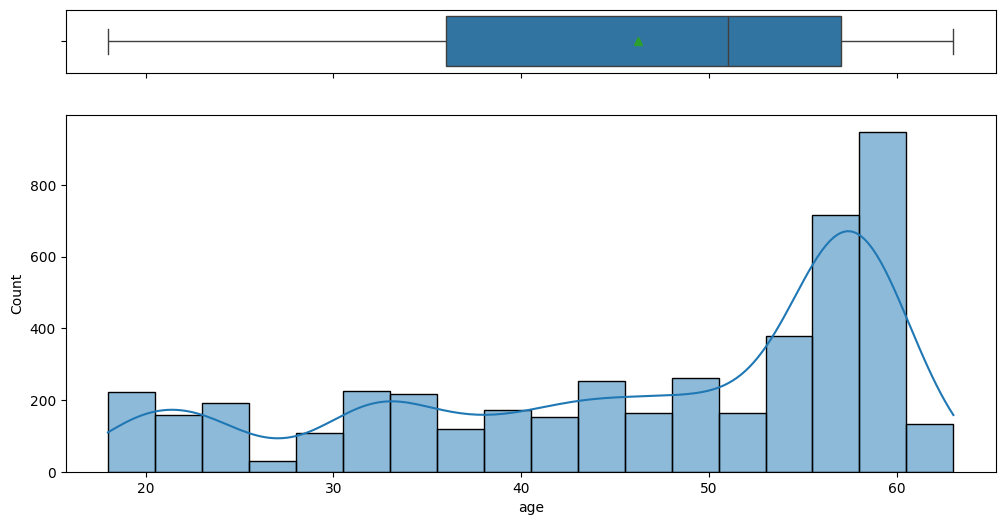

In [70]:
#histogram and boxplot of age
hist_box(data,'age')

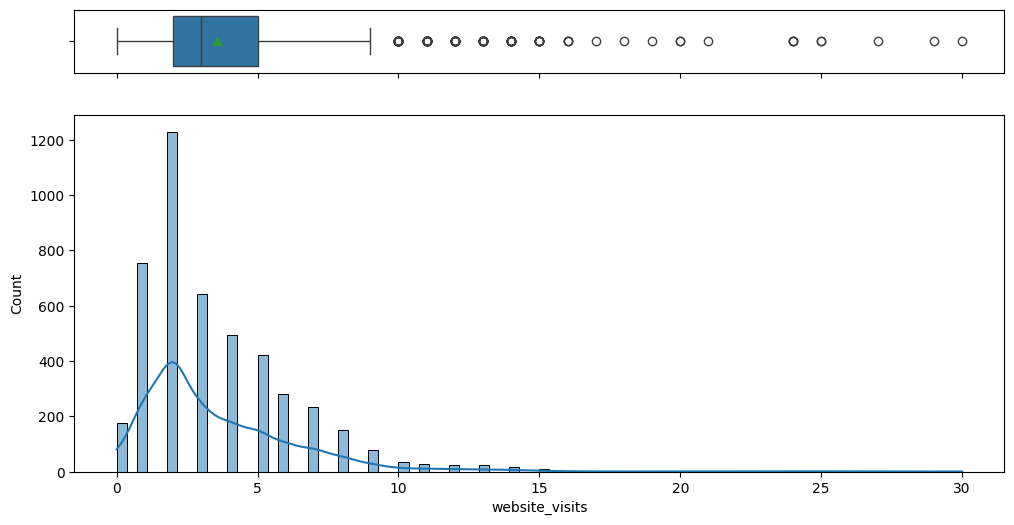

In [71]:
#histogram and boxplot of website_visits
hist_box(data,'website_visits')

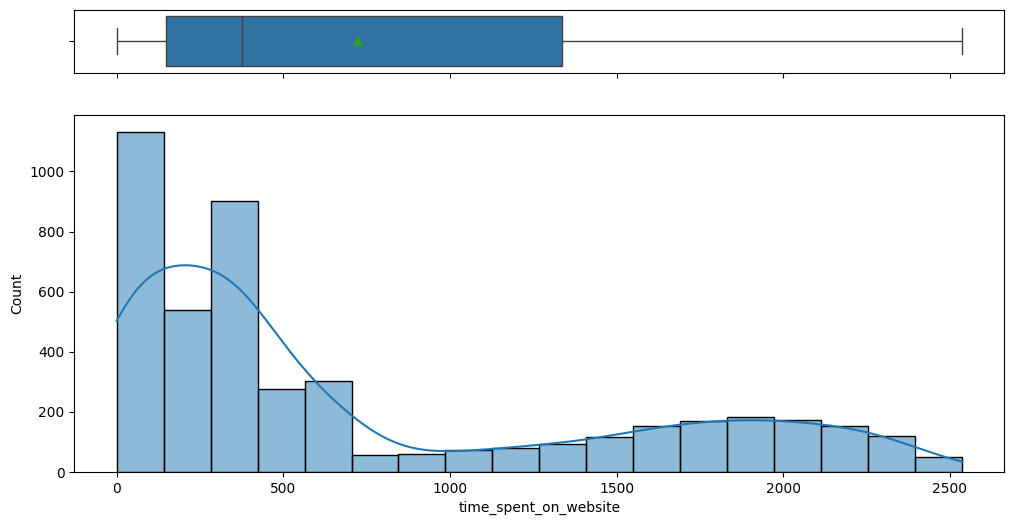

In [72]:
#histogram and boxplot of time_spent_on_website
hist_box(data,'time_spent_on_website')

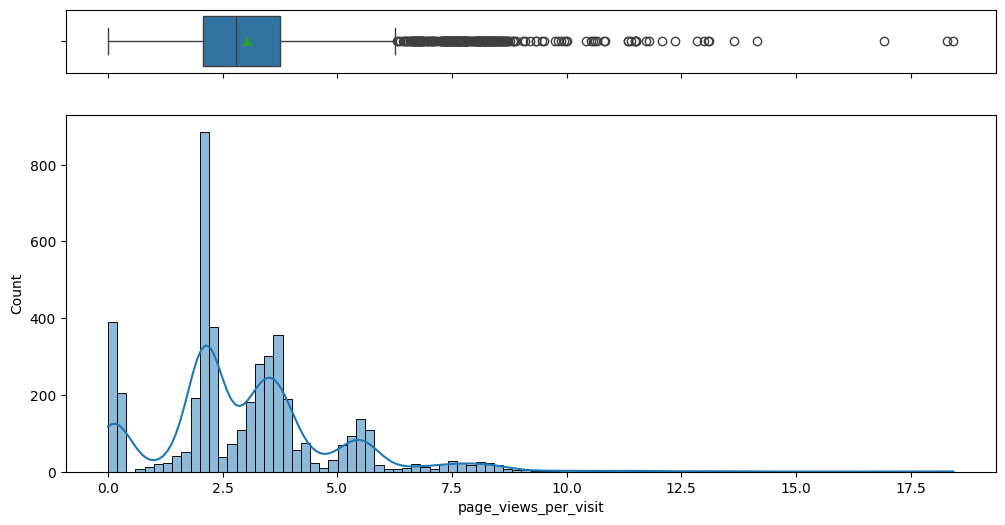

In [73]:
#histogram and boxplot of page_views_per_visit
hist_box(data,'page_views_per_visit')

In [74]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

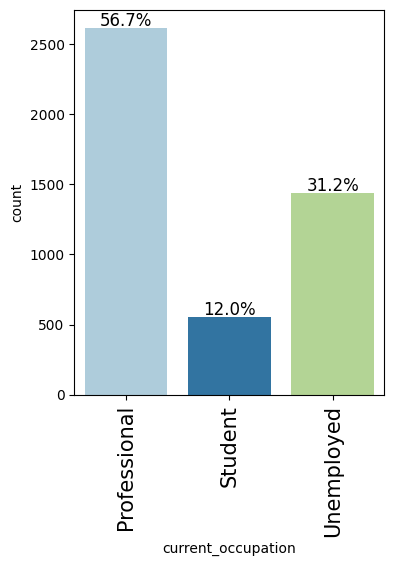

In [75]:
#barplot for current occupation
labeled_barplot(data, "current_occupation", perc=True)

Observation:

* 56.7% of leads are profressionals who want to upskill or change career path.
* 31.2% are unemployed who want to enhance their employability.
* The remaining 12% are students.  

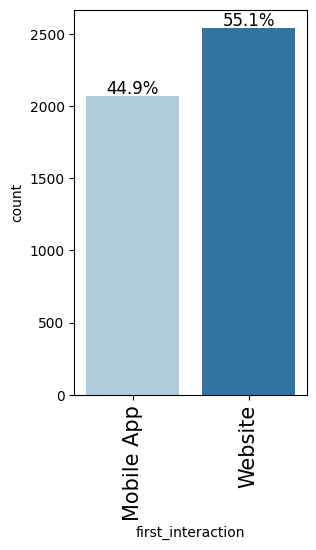

In [76]:
#barplot for first interaction
labeled_barplot(data, "first_interaction", perc=True)

Observation:

* 55.1% of the leads first interaction was on the website; both platforms are important for lead generation with 44.9% of the leads first interacting via the Mobile App.

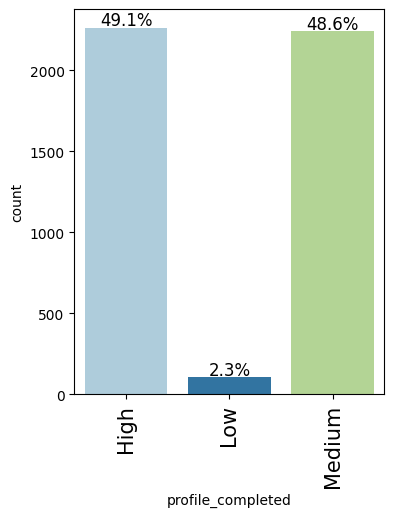

In [77]:
#barplot for profile completed
labeled_barplot(data, "profile_completed", perc=True)

Observation:

* A significant majority of leads have either High (49.1%) or Medium (48.6%) profile completion, indicating strong engagement with the platform

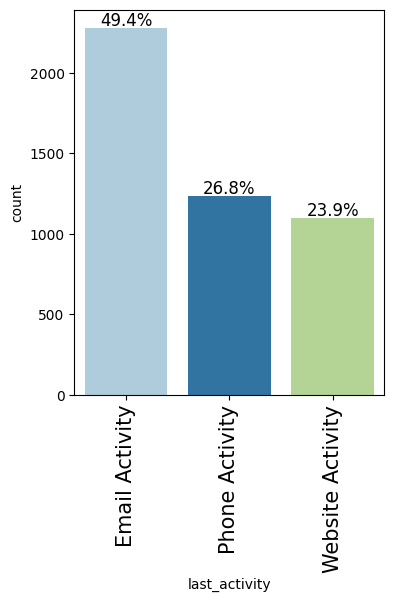

In [78]:
#barplot for last activity
labeled_barplot(data, "last_activity", perc=True)

Observation:

* Email remains the dominant channel for lead engagement, representing 49.4% of last recorded activities. This suggests that email communication is highly effective for delivering program information and facilitating conversions. Phone Activity accounts for 26.8%, indicating a notable preference for direct verbal interaction. Website Activity, at 23.9%, appears to function primarily as an initial contact point. The data implies that leads initiating contact via the website are often transitioned to email, where detailed interactions and deal closures are more likely to occur.

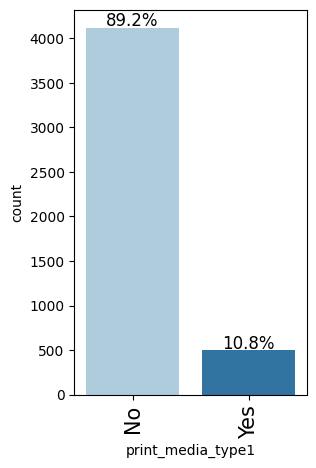

In [79]:
#barplot for print_media_type1
labeled_barplot(data, "print_media_type1", perc=True)

Observation:

* Only 10.8% of leads have seen the ads on the Newspaper. This means that newspaper advertising has limited reach among the target audience and may not be a primary driver of lead generation. The data suggests that reallocating resources toward more impactful channels could improve marketing efficiency.

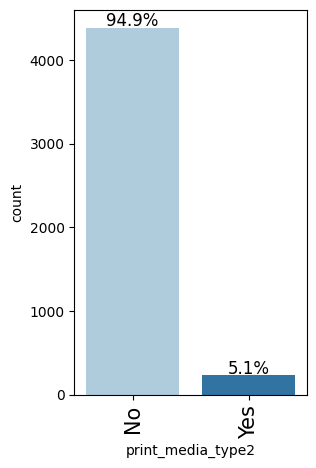

In [80]:
#barplot for print_media_type2
labeled_barplot(data, "print_media_type2", perc=True)

Observation:

* Just like in the newspaper, Only 5.1% of leads have seen the ads in the Magazine. Meaning that magazines also have limited reach among the target audience and may not be a primary driver of lead generation. The data suggests that reallocating resources toward more impactful channels could improve marketing efficiency.

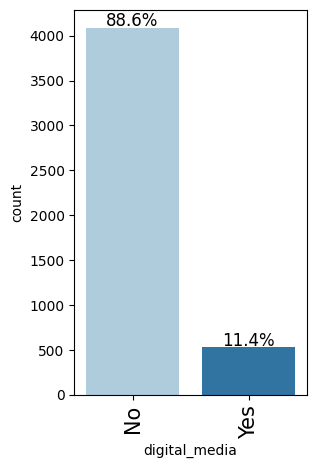

In [81]:
#barplot for digital media
labeled_barplot(data, "digital_media", perc=True)

Observation:

* Only 11.4% of leads reported exposure to ExtraaLearn through digital media platforms. This indicates that digital media currently plays a minimal role in lead acquisition. Given the broad reach and cost-efficiency of digital channels, their current underutilization highlights a strategic opportunity to enhance marketing efforts and increase brand visibility among potential leads.

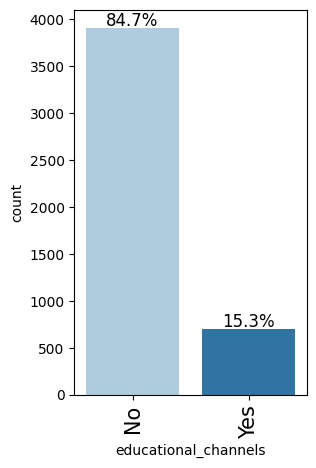

In [82]:
#barplot for educational_channels
labeled_barplot(data, "educational_channels", perc=True)

Observation:

* 15.3% of leads reported discovering ExtraaLearn through educational channels.This indicates that educational channels are currently underleveraged in the marketing strategy. Given their relevance to the target audience, increasing presence in these spaces could enhance brand credibility and attract more qualified leads.

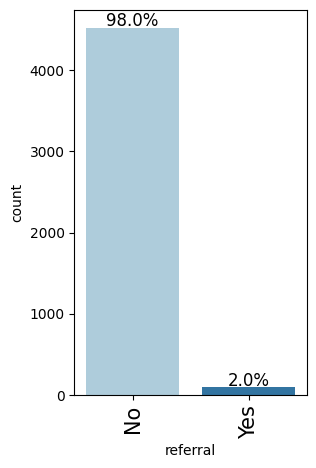

In [83]:
#barplot for referral
labeled_barplot(data, "referral", perc=True)

Observation:

 * 2.0% of leads were acquired through referrals indicating that referral marketing is currently underutilized. Given its potential for high-quality lead generation and cost-effectiveness, there is a strategic opportunity to develop and promote referral programs to enhance customer acquisition.

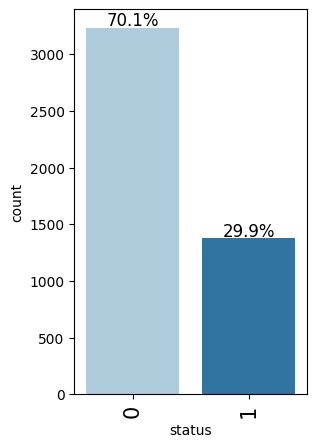

In [84]:
#barplot for status
labeled_barplot(data, "status", perc=True)

Observation:

* Only 29.9% of leads were successfully converted to paid customers, while the remaining 70.1% did not convert indicating a relatively low conversion rate, suggesting potential gaps in the lead nurturing process.

In [85]:
def plot_stacked_bar(df, category_col, status_col, title):
    """
    Plots a stacked bar chart showing the relationship between a categorical feature and lead status.

    Parameters:
    -----------
    df : pandas.DataFrame
        The dataset containing leads and related information.
    category_col : str
        The name of the categorical column (e.g., 'Occupation', 'First Interaction Channel').
    status_col : str
        The column representing lead outcome (e.g., 'Lead_Status').
    title : str
        The title of the chart (e.g., 'Effect of Occupation on Lead Status').
    """

    # Create a crosstab (count of lead status per category)
    cross_tab = pd.crosstab(df[category_col], df[status_col])

    # Normalize to show percentage within each category (optional)
    cross_tab_perc = cross_tab.div(cross_tab.sum(axis=1), axis=0) * 100

    # Plot the stacked bar chart
    cross_tab_perc.plot(kind='bar', stacked=True, figsize=(10, 6))

    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel(category_col, fontsize=12)
    plt.ylabel('Percentage (%)', fontsize=12)
    plt.legend(title=status_col, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

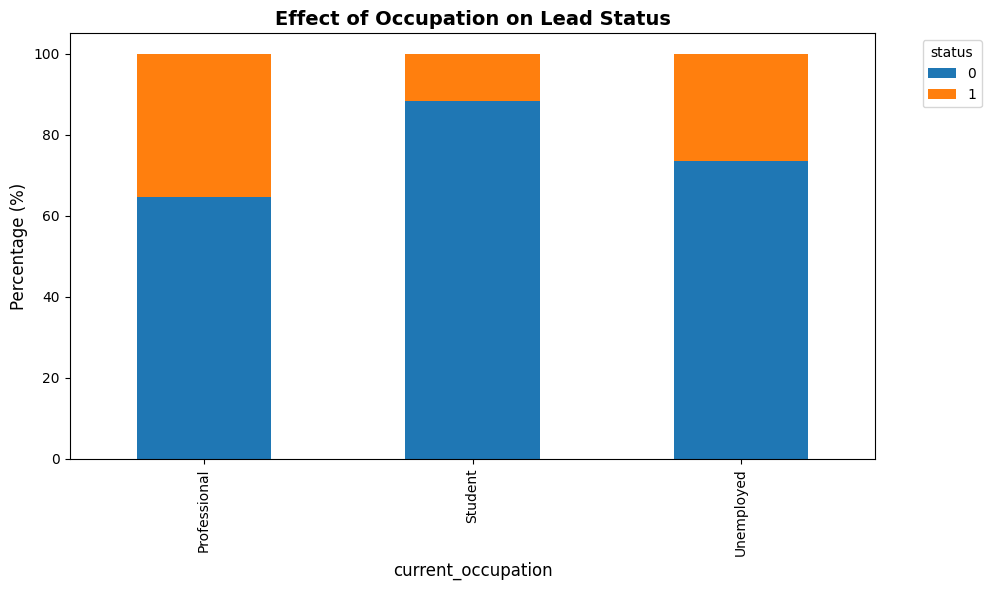

In [86]:
plot_stacked_bar(data, 'current_occupation', 'status', 'Effect of Occupation on Lead Status')

Observation:

We can see that there are more conversions in the leads that are proffessionals because they need to upskill or change career path. while we have a few conversion in the lead status in the unemployed who maybe trying to build their profile. Students have lesser conversion rate probably because they have not figured out the need for taking courses.

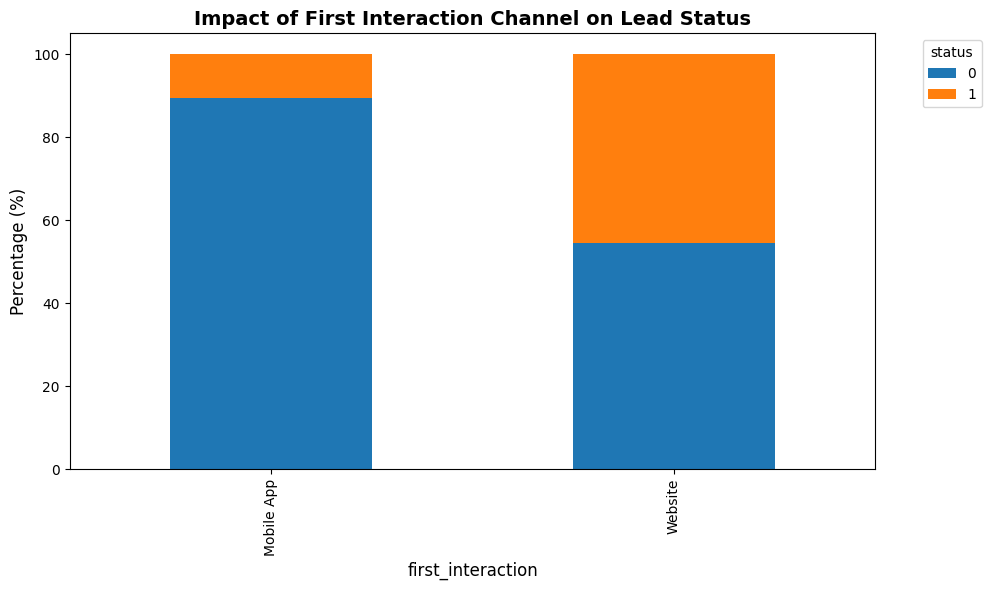

In [87]:
plot_stacked_bar(data, 'first_interaction', 'status', 'Impact of First Interaction Channel on Lead Status')

Observation:

The conversion rate is higher among leads whose first interaction occurred through the website.

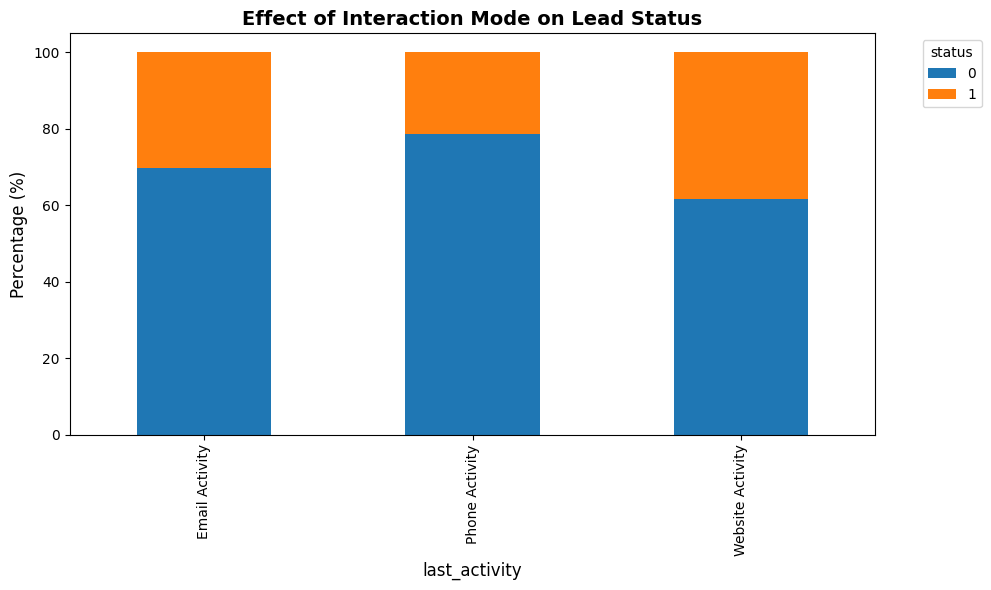

In [88]:
plot_stacked_bar(data, 'last_activity', 'status', 'Effect of Interaction Mode on Lead Status')


Observation:

Among the different interaction modes, Website Activity works best, yielding the highest lead conversion rate. While phone activity shows the lowest conversion rate.

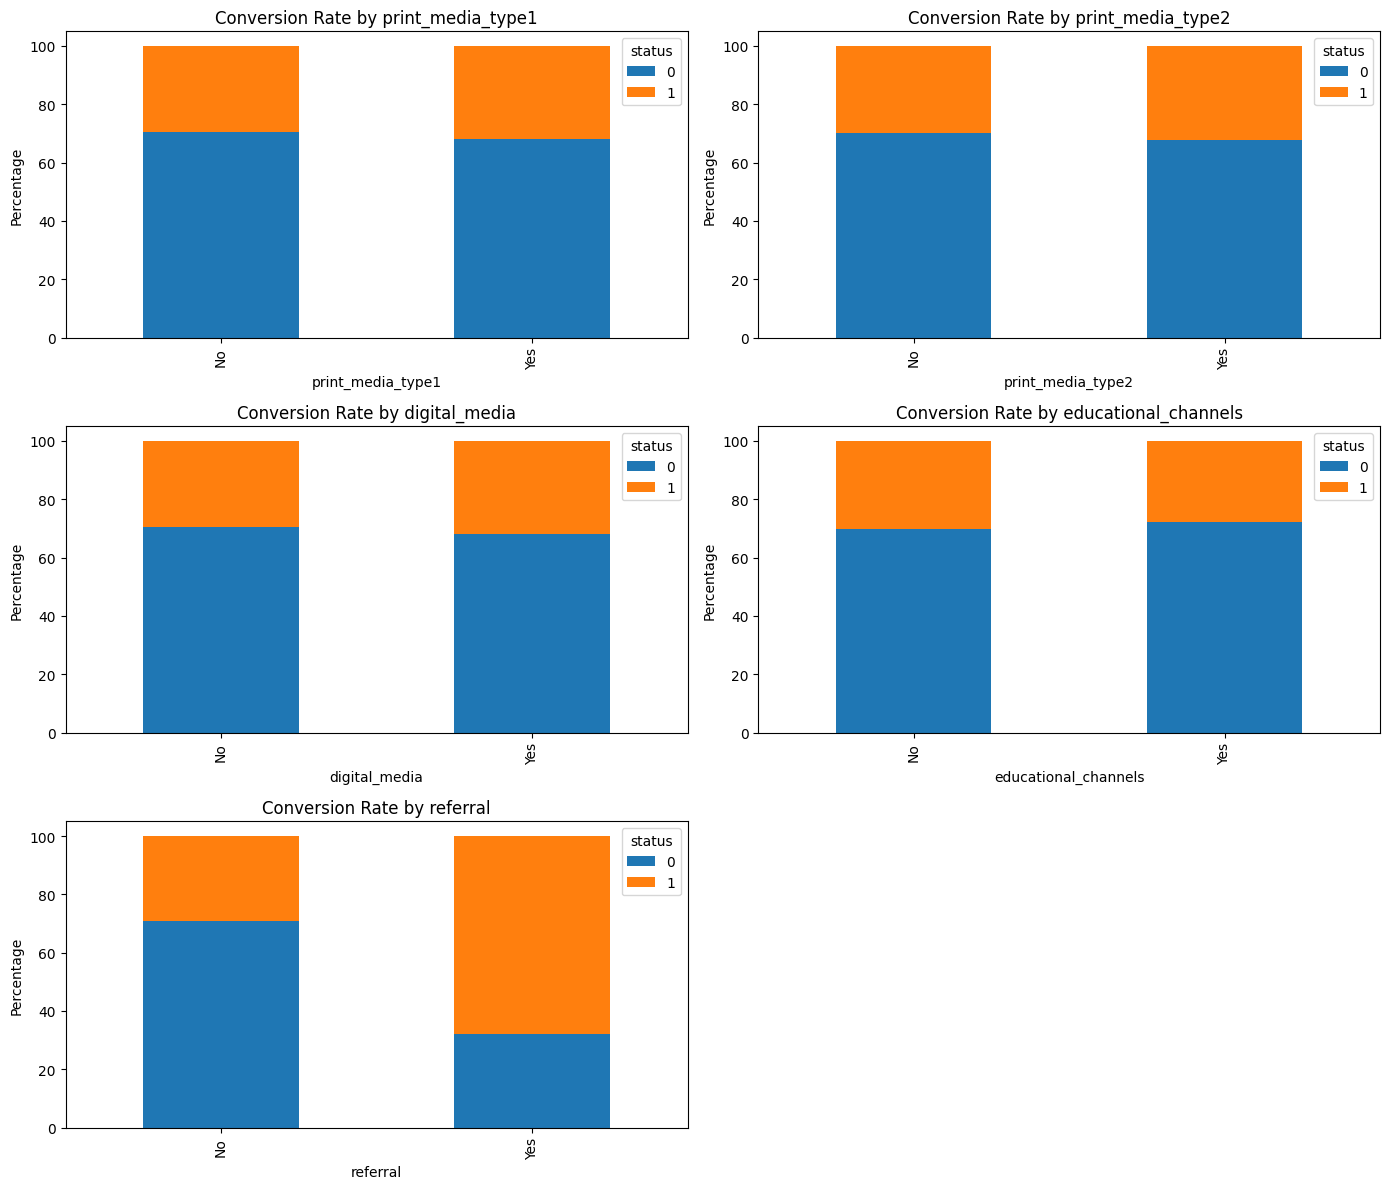

In [89]:

 #Define the function to plot a stacked bar chart
def plot_stacked_bar_sub(ax, data, category_col, target_col, title):
    crosstab = pd.crosstab(data[category_col], data[target_col], normalize='index') * 100
    crosstab.plot(kind='bar', stacked=True, ax=ax)
    ax.set_title(title)
    ax.set_ylabel('Percentage')
    ax.legend(title=target_col)

# Create subplots (3 rows, 2 columns)
fig, axs = plt.subplots(3, 2, figsize=(14, 12))
axs = axs.flatten()

# Plot each chart in a subplot
plot_stacked_bar_sub(axs[0], data, 'print_media_type1', 'status', 'Conversion Rate by print_media_type1')
plot_stacked_bar_sub(axs[1], data, 'print_media_type2', 'status', 'Conversion Rate by print_media_type2')
plot_stacked_bar_sub(axs[2], data, 'digital_media', 'status', 'Conversion Rate by digital_media')
plot_stacked_bar_sub(axs[3], data, 'educational_channels', 'status', 'Conversion Rate by educational_channels')
plot_stacked_bar_sub(axs[4], data, 'referral', 'status', 'Conversion Rate by referral')

# Remove the unused subplot (6th one)
fig.delaxes(axs[5])

# Adjust layout
plt.tight_layout()
plt.show()


Observation:

From the above charts we can see that referral has the highest conversion rate.While Digital media has the lowest conversion rate.

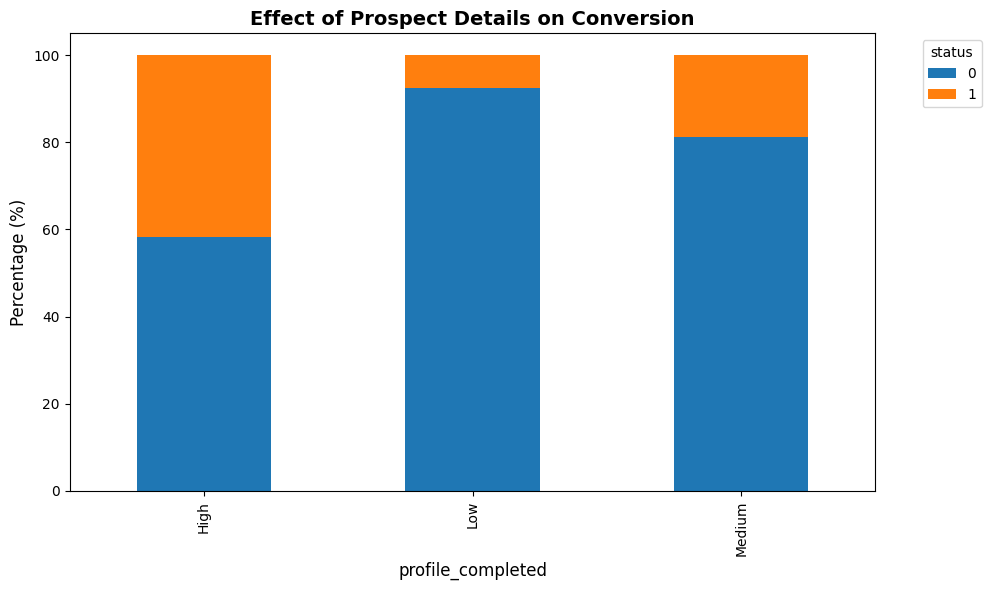

In [90]:
plot_stacked_bar(data, 'profile_completed', 'status', 'Effect of Prospect Details on Conversion')

Observation:

Leads that completely fill their profile are more likely to convert. Hence the higher conversion rate for the completly filled profile and leads with low completed profile have little conversion rate and are less likely to convert.

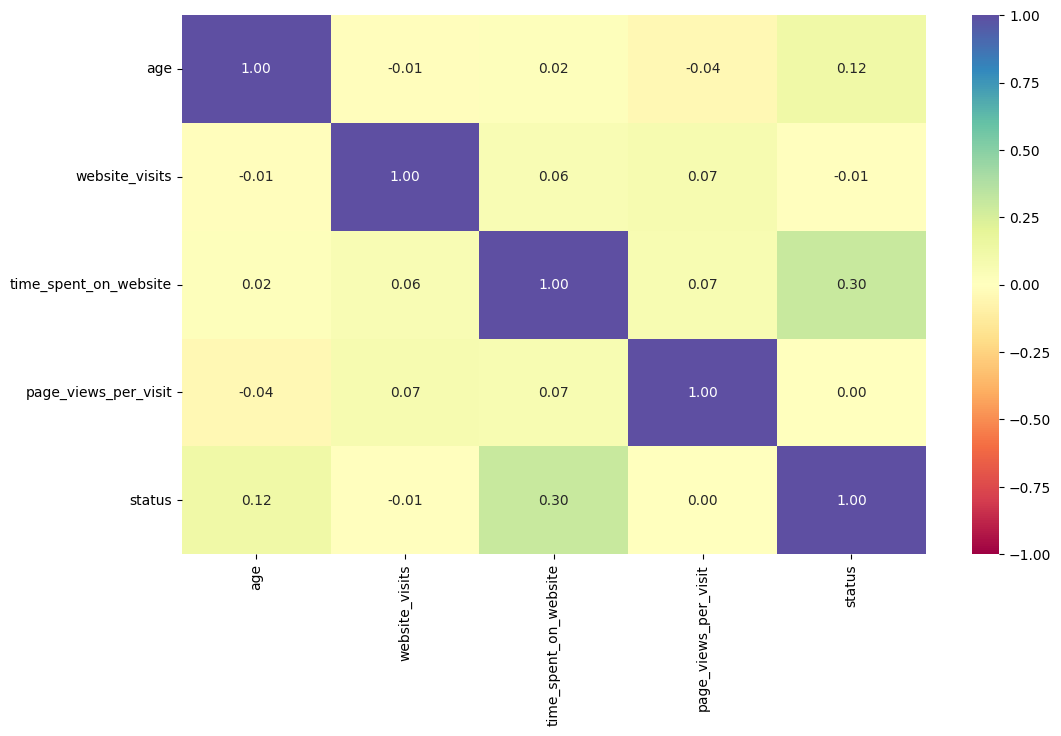

In [91]:
#Bivariate analysis
cols_list = data.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(12, 7))
sns.heatmap(
    data[cols_list].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral"
)
plt.show()

Observation:

There is no strong correlation among the variables. Time_spent_on_website with a value of 0.3 will be a stronger predictor of conversion than the other variables.

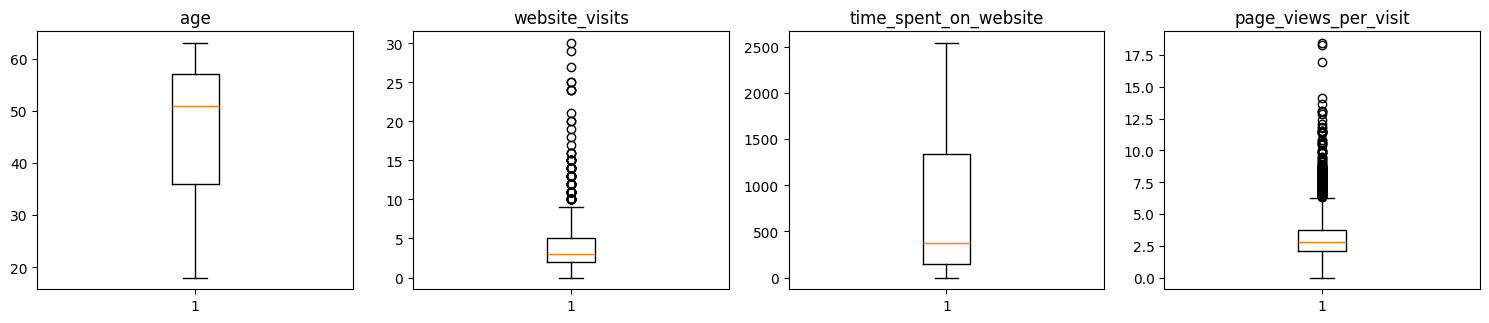

In [92]:
# outlier detection using boxplot
numeric_columns = data.select_dtypes(include=np.number).columns.tolist()

# dropping release_year as it is a temporal variable
numeric_columns.remove("status")

plt.figure(figsize=(15, 12))

for i, variable in enumerate(numeric_columns):
    plt.subplot(4, 4, i + 1)
    plt.boxplot(data[variable], whis=1.5)
    plt.tight_layout()
    plt.title(variable)

plt.show()

Observations:

Age and time_spent_on_website do not have outliers while website visit has significant outliers which means that some leads sent significant amount of time on the website. Page_views_per_visit has a lot of outliers which means that leads are viewing more pages per visit.

In [93]:
#data preprocessing for the modeling
X = data.drop(["status"], axis=1)
Y = data["status"]

#using one hot encoding to encode categorical features
X = pd.get_dummies(X,drop_first=True)

# Splitting the data in 70:30 ratio for train to test data
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.30, random_state=1)

In [94]:
print("Shape of Training set : ", X_train.shape)
print("Shape of test set : ", X_test.shape)

Shape of Training set :  (3228, 16)
Shape of test set :  (1384, 16)


## Building a Decision Tree model

In [95]:
# Creating metric function
def metrics_score(actual, predicted):
    print(classification_report(actual, predicted))

    cm = confusion_matrix(actual, predicted)
    plt.figure(figsize=(8,5))

    sns.heatmap(cm, annot=True,  fmt='.2f')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

In [96]:
# Fitting the decision tree classifier on the training data
d_tree =  DecisionTreeClassifier(random_state=1)
d_tree.fit(X_train, y_train)



DecisionTreeClassifier(random_state=1)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2273
           1       1.00      1.00      1.00       955

    accuracy                           1.00      3228
   macro avg       1.00      1.00      1.00      3228
weighted avg       1.00      1.00      1.00      3228



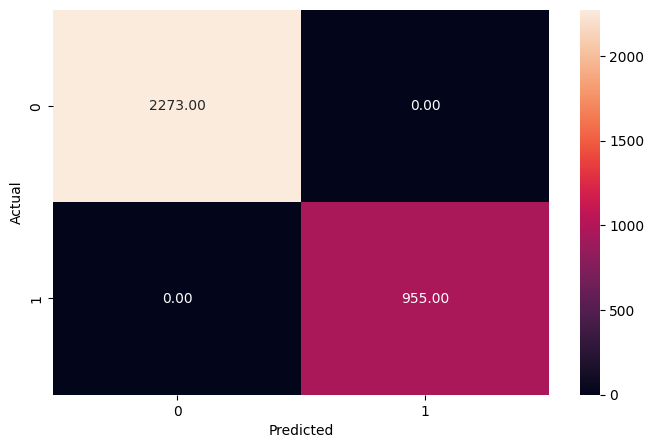

In [97]:
#Predicting and evaluating performance on the training data
y_pred_train1 = d_tree.predict(X_train)
metrics_score(y_train, y_pred_train1)

Observation:

The model achieved 100% accuracy, it correctly predicted every single instance. We will go ahead to check the test set.

              precision    recall  f1-score   support

           0       0.87      0.86      0.86       962
           1       0.69      0.70      0.70       422

    accuracy                           0.81      1384
   macro avg       0.78      0.78      0.78      1384
weighted avg       0.81      0.81      0.81      1384



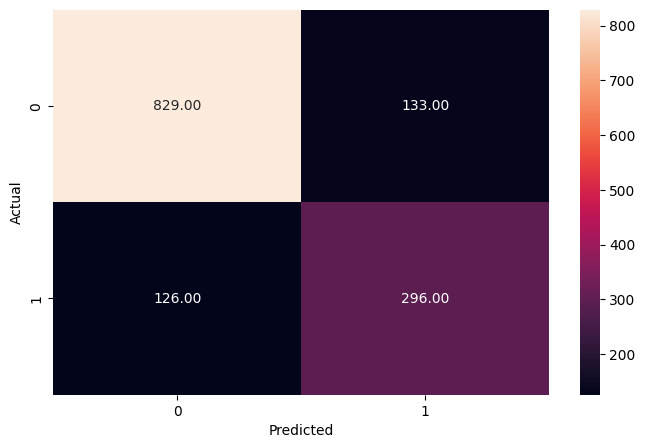

In [98]:
#Predicting and evaluating performance on test data
y_pred_test1 = d_tree.predict(X_test)
metrics_score(y_test, y_pred_test1)

Observation:

The model achieved an accuracy of 81%; the model performs better on class 0 than on class 1 as we can see the samples for class 0 is 962 wile that of class 1 is 422.
The model struggles with class 1 and this might be due to overfitting of the majority class. We will go ahead and prune the tree.

## Do we need to prune the tree?

In [99]:
# Select a classifier and configure it to assign more importance to Class 1 by setting its weight to 0.7
d_tree_tuned = DecisionTreeClassifier(random_state = 7, class_weight = {0: 0.3, 1: 0.7})

# Grid of parameters to choose from
parameters = {'max_depth': np.arange(2, 10),
              'criterion': ['gini', 'entropy'],
              'min_samples_leaf': [5, 10, 20, 25]
             }

# Type of scoring used to compare parameter combinations - recall score for class 1
scorer = metrics.make_scorer(recall_score, pos_label = 1)

# Run the grid search
grid_obj = GridSearchCV(d_tree_tuned, parameters, scoring = scorer, cv = 5)

grid_obj = grid_obj.fit(X_train, y_train)

# Set the classifier to the best combination of parameters
d_tree_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data
d_tree_tuned.fit(X_train, y_train)

DecisionTreeClassifier(class_weight={0: 0.3, 1: 0.7}, criterion='entropy',
                       max_depth=np.int64(3), min_samples_leaf=5,
                       random_state=7)

              precision    recall  f1-score   support

           0       0.94      0.77      0.85      2273
           1       0.62      0.88      0.73       955

    accuracy                           0.80      3228
   macro avg       0.78      0.83      0.79      3228
weighted avg       0.84      0.80      0.81      3228



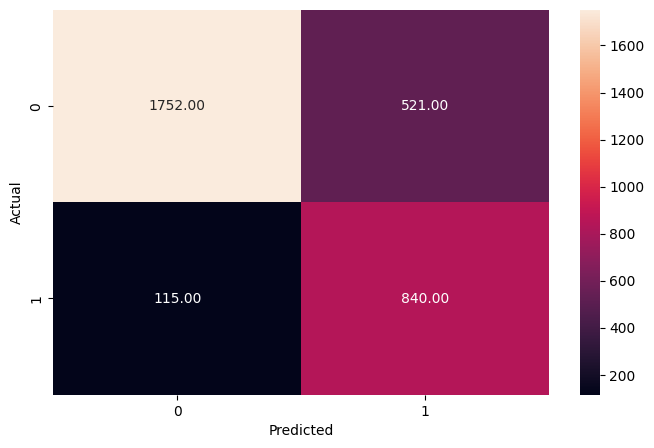

In [100]:
#Predicting and evaluating performance on the training data
y_pred_train2 = d_tree_tuned.predict(X_train)
metrics_score(y_train, y_pred_train2)

Observation:

This tuned model now prioritizes class 1 as the recall has risen to 0.88 while the recall for class 0 is 0.77 due to the increased weight on class 1.
The model achieved 80% accuracy.
We will go ahead and check the test.

              precision    recall  f1-score   support

           0       0.93      0.77      0.84       962
           1       0.62      0.86      0.72       422

    accuracy                           0.80      1384
   macro avg       0.77      0.82      0.78      1384
weighted avg       0.83      0.80      0.80      1384



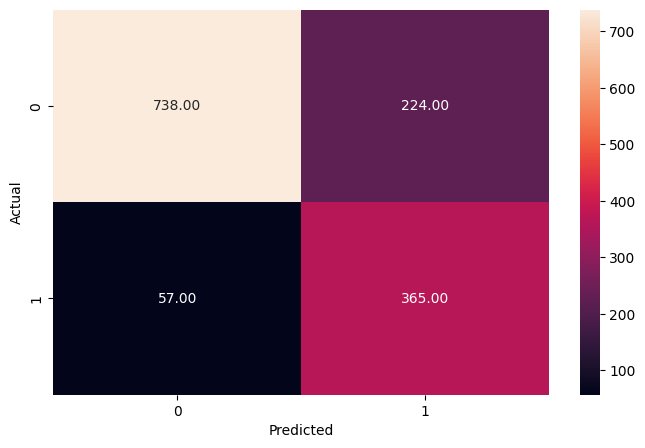

In [101]:
y_pred_test2 = d_tree_tuned.predict(X_test)
metrics_score(y_test, y_pred_test2)

Observation:

The model achieves 80% accuracy on the test set, which is consistent with the training accuracy — a good sign of reduced overfitting.

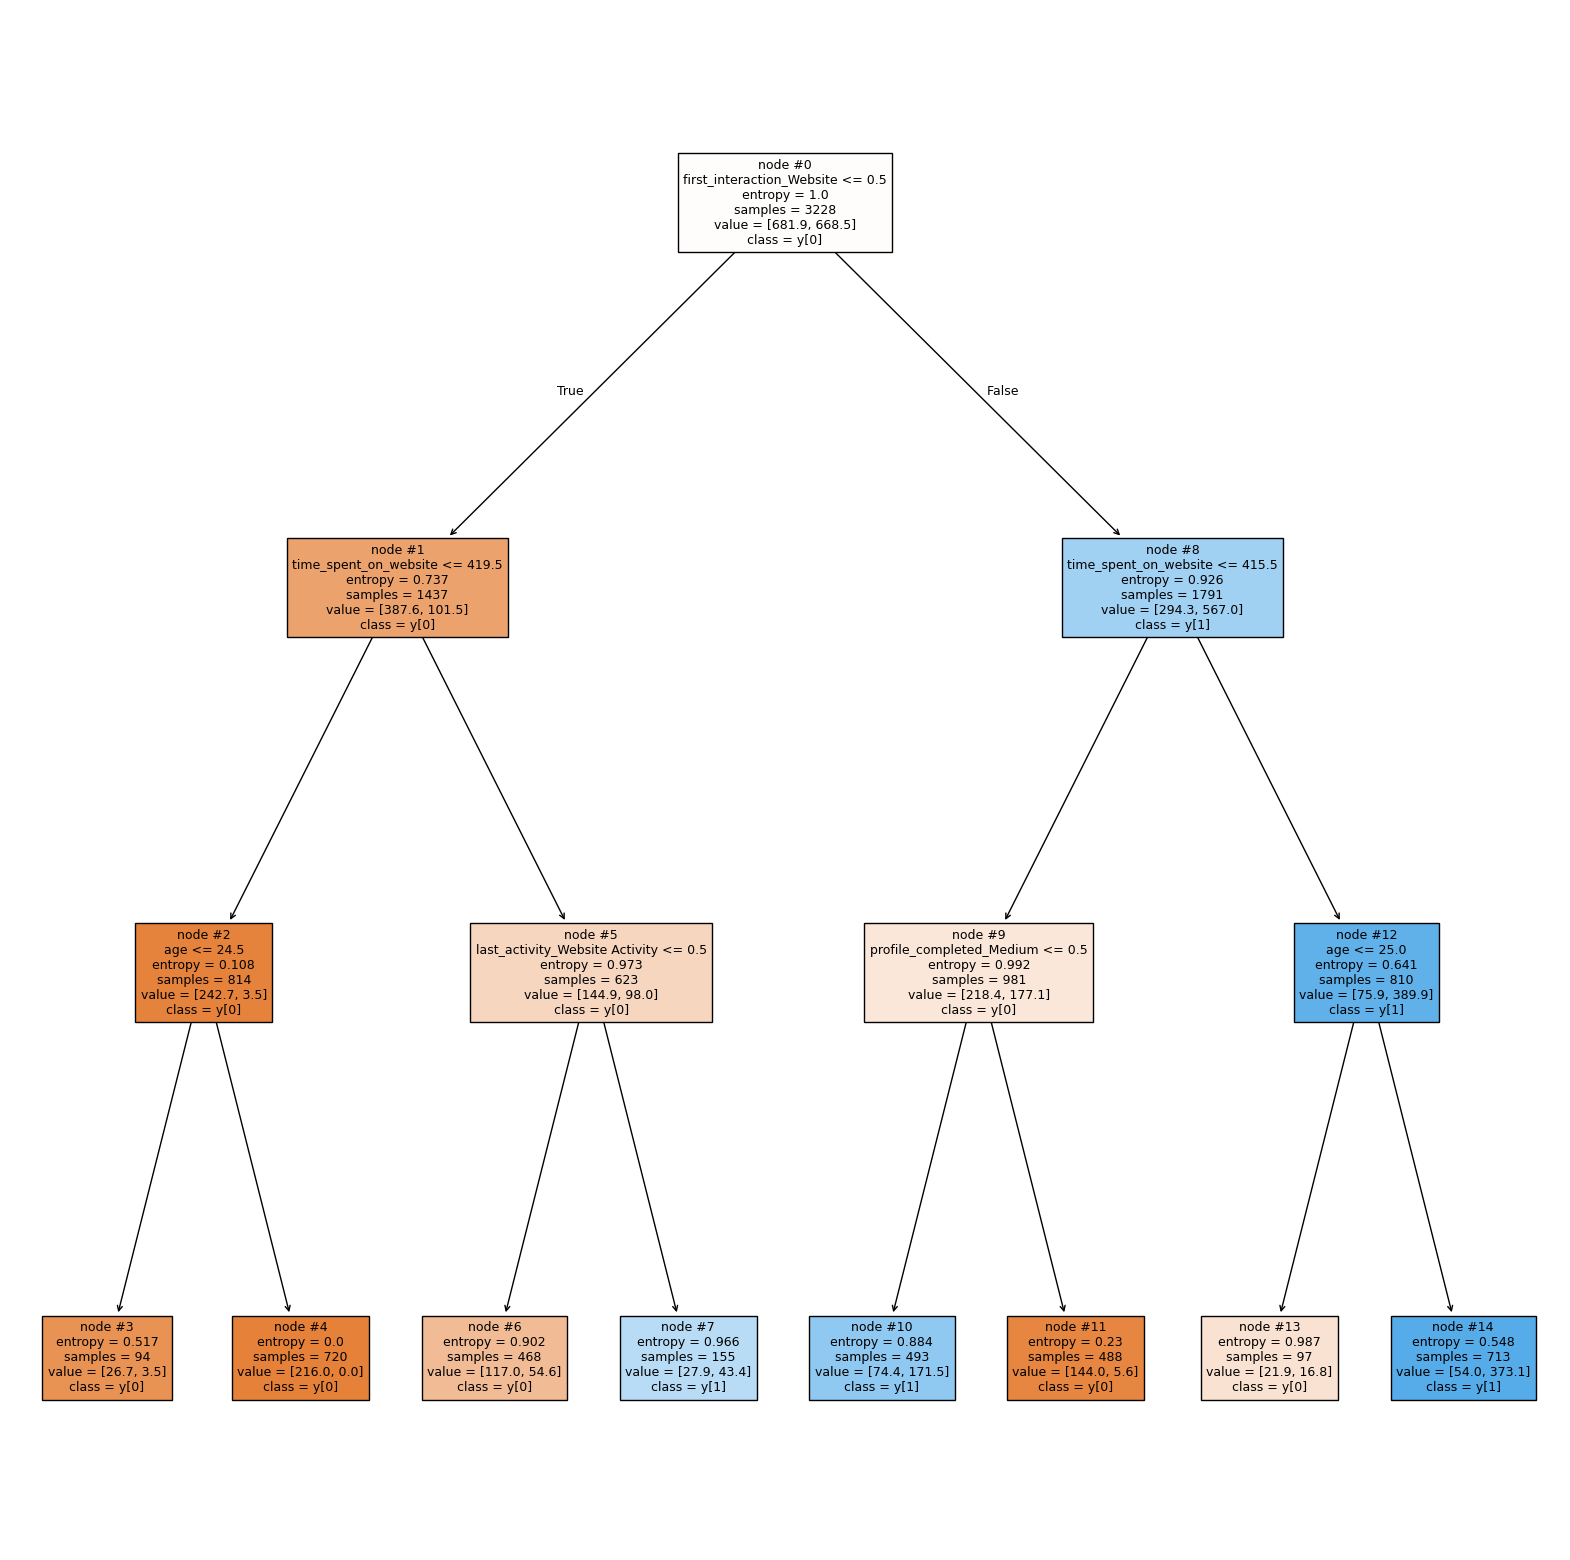

In [102]:
#visualizing the decision tree
features = list(X.columns)

plt.figure(figsize = (20, 20))

tree.plot_tree(d_tree_tuned, feature_names = features, filled = True, fontsize = 9, node_ids = True, class_names = True)

plt.show()

Observation:

The tree's first split is at first_interaction which shows that it is the most important feature for the initial decision.
time_spent_on_website, age, last_activity, profile_completed are other important features used in the tree.

In [103]:
# Importance of features in the tree building

print (pd.DataFrame(d_tree_tuned.feature_importances_, columns = ["Imp"], index = X_train.columns).sort_values(by = 'Imp', ascending = False))

                                   Imp
time_spent_on_website          0.34814
first_interaction_Website      0.32718
profile_completed_Medium       0.23927
age                            0.06389
last_activity_Website Activity 0.02151
current_occupation_Student     0.00000
page_views_per_visit           0.00000
website_visits                 0.00000
profile_completed_Low          0.00000
current_occupation_Unemployed  0.00000
last_activity_Phone Activity   0.00000
print_media_type1_Yes          0.00000
print_media_type2_Yes          0.00000
digital_media_Yes              0.00000
educational_channels_Yes       0.00000
referral_Yes                   0.00000


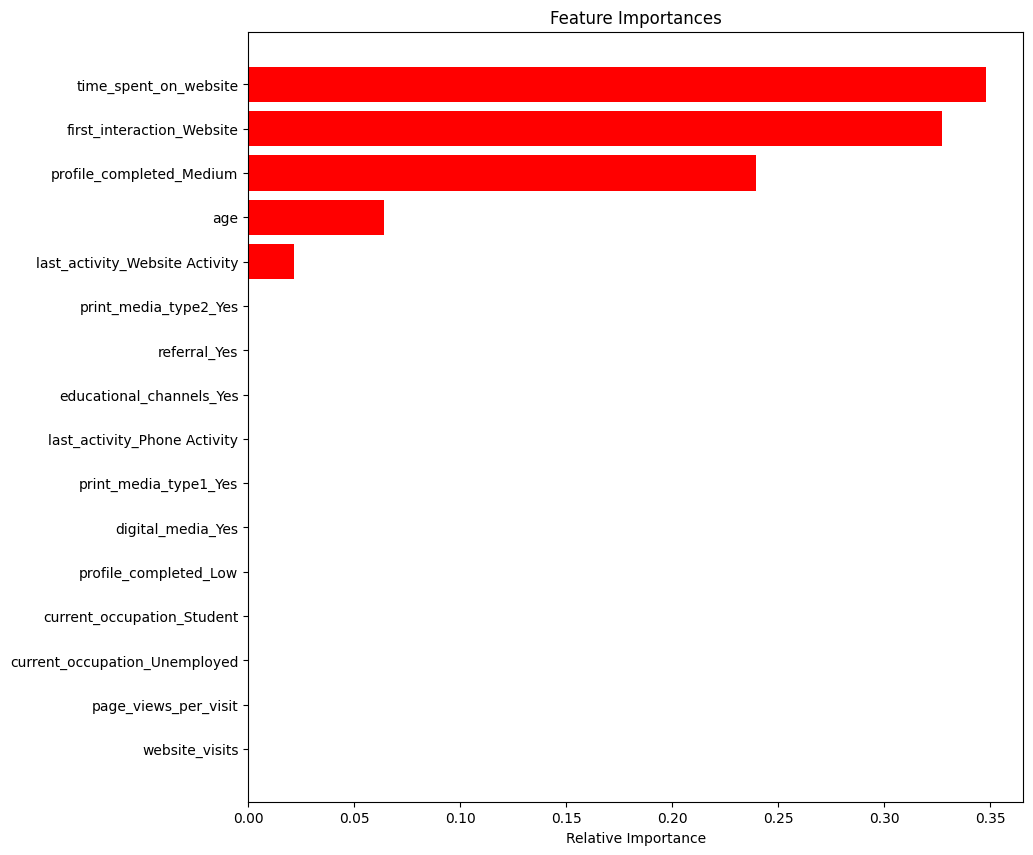

In [104]:
# Plotting the feature importance
importances = d_tree_tuned.feature_importances_

indices = np.argsort(importances)

plt.figure(figsize = (10, 10))

plt.title('Feature Importances')

plt.barh(range(len(indices)), importances[indices], color = 'red', align = 'center')

plt.yticks(range(len(indices)), [features[i] for i in indices])

plt.xlabel('Relative Importance')

plt.show()

From the above chart time_spent_on_website is the most important feature in the model. first_interaction_Website, profile_completed_Medium, age are also predictors of notable importance.

## Building a Random Forest model

In [105]:
# Fitting a Random Forest classifier on the training data

rf = RandomForestClassifier(random_state=1)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=1)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2273
           1       1.00      1.00      1.00       955

    accuracy                           1.00      3228
   macro avg       1.00      1.00      1.00      3228
weighted avg       1.00      1.00      1.00      3228



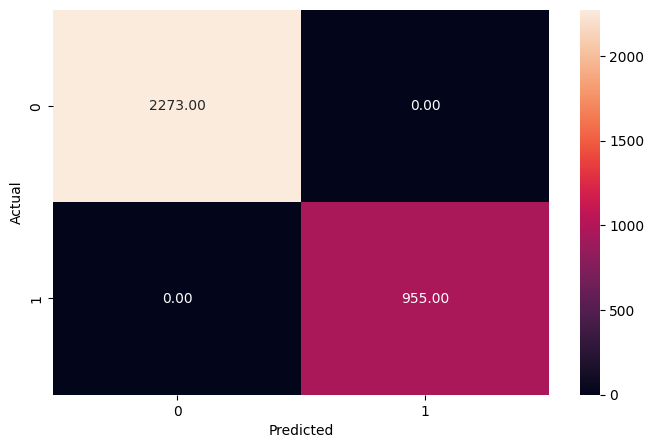

In [106]:
# Predict and evaluate the performance of the model
y_pred_train3 = rf.predict(X_train)
metrics_score(y_train, y_pred_train3)

Observation:

The model achieved a 100% accuracy. Such perfect scores are highly unusual in real-world data and strongly suggest overfitting.
We will run it on our test data.

              precision    recall  f1-score   support

           0       0.87      0.91      0.89       962
           1       0.78      0.68      0.73       422

    accuracy                           0.84      1384
   macro avg       0.82      0.80      0.81      1384
weighted avg       0.84      0.84      0.84      1384



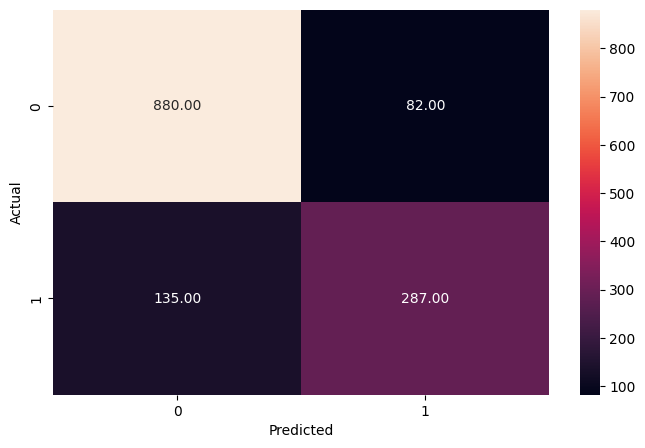

In [107]:
# Fitting a Random Forest classifier on the test data
y_pred_test3 = rf.predict(X_test)
metrics_score(y_test, y_pred_test3)

Observation:

The model has 84% accuracy. Class 0 has high precision(0.87) and recall(0.91) while precision for Class 1 is 0.78 and a lower recall 0.68.
The model performs very well on Class 0 and reasonably well on Class 1, though there's room to improve recall for Class 1.

We will go ahead and prune the tree.

## Do we need to prune the tree?

In [108]:
# Choose the type of classifier
rf_tuned = RandomForestClassifier(criterion = "entropy", random_state = 7)

# Grid of parameters to choose from
parameters = {"n_estimators": [110, 120],
    "max_depth": [6, 7],
    "min_samples_leaf": [20, 25],
    "max_features": [0.8, 0.9],
    "max_samples": [0.9, 1],
    "class_weight": ["balanced",{0: 0.3, 1: 0.7}]
             }

# Type of scoring used to compare parameter combinations - recall score for class 1
scorer = metrics.make_scorer(recall_score, pos_label = 1)

# Run the grid search on the training data using scorer=scorer and cv=5
grid_obj = GridSearchCV(rf_tuned, parameters, cv=5,scoring='recall',n_jobs=-1)

grid_obj = grid_obj.fit(X_train, y_train)

# Save the best estimator to variable rf_tuned
rf_tuned = grid_obj.best_estimator_


In [109]:
# Fitting the best algorithm to the training data
rf_tuned.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', criterion='entropy',
                       max_depth=6, max_features=0.8, max_samples=0.9,
                       min_samples_leaf=25, n_estimators=120, random_state=7)

              precision    recall  f1-score   support

           0       0.94      0.83      0.88      2273
           1       0.68      0.87      0.76       955

    accuracy                           0.84      3228
   macro avg       0.81      0.85      0.82      3228
weighted avg       0.86      0.84      0.84      3228



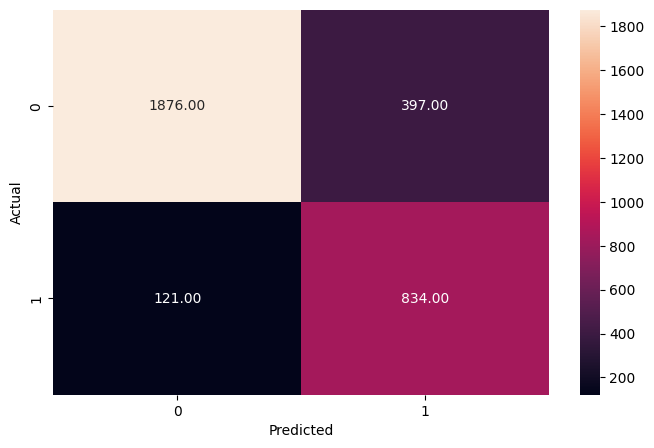

In [110]:
# Checking performance on the training data
y_pred_train4 = rf_tuned.predict(X_train)
metrics_score(y_train, y_pred_train4)

Observation:

The accuracy of the tuned model is 84%.
High precision (0.94) and good recall (0.83) indicate the model is confident and mostly correct when predicting Class 0.
Recall is high (0.87), meaning the model is catching most of the actual Class 1 cases and Precision is lower (0.68), suggesting some false positives — the model sometimes predicts Class 1 when it's actually Class 0.
The tuning has successfully reduced overfitting and improved the model’s ability to generalize.

              precision    recall  f1-score   support

           0       0.93      0.83      0.87       962
           1       0.68      0.85      0.76       422

    accuracy                           0.83      1384
   macro avg       0.81      0.84      0.82      1384
weighted avg       0.85      0.83      0.84      1384



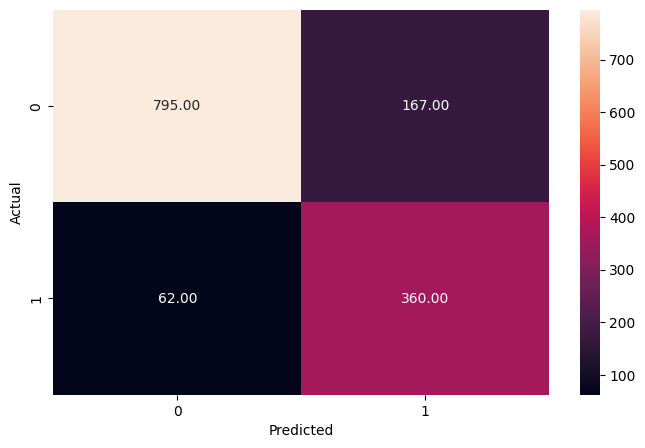

In [111]:
# Checking performance on the test data
y_pred_test4 = rf_tuned.predict(X_test)
metrics_score(y_test, y_pred_test4)

Observation:

* The model achieved 83% accuracy, which is consistent with the training performance — a good sign of generalization.
* Class 0 has High precision (0.93) and good recall (0.83) indicating that the model is very effective at identifying the Class correctly.
* In Class 1 the Recall is high (0.85) and Precision is lower (0.68), indicating some false positives — the model sometimes predicts Class 1 when it's actually Class 0.
* The model is well-tuned, showing strong generalization and good balance between precision and recall.

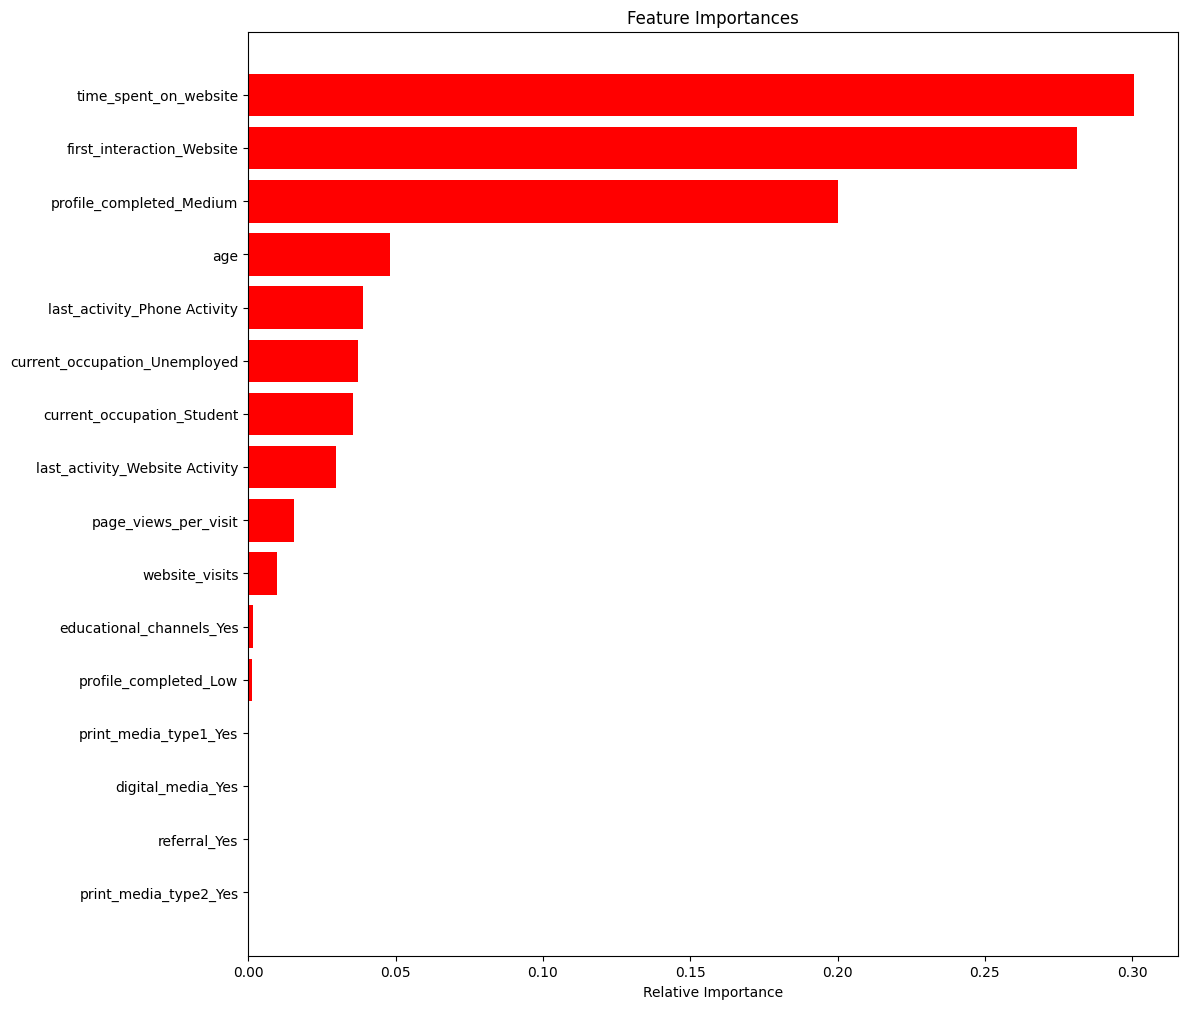

In [112]:
# Plotting the feature importance
importances = rf_tuned.feature_importances_

indices = np.argsort(importances)

feature_names = list(X.columns)

plt.figure(figsize = (12, 12))

plt.title('Feature Importances')

plt.barh(range(len(indices)), importances[indices], color = 'red', align = 'center')

plt.yticks(range(len(indices)), [feature_names[i] for i in indices])

plt.xlabel('Relative Importance')

plt.show()

Observation:

* The top influential features of the model are time_spent_on_website, first_interaction_Website, profile_completed_Medium.
* The moderately important features are age, last_activity_Phone_activity, current_ocupation_Unemployed.

## Actionable Insights and Recommendations

Conclusion:

The random forest model out performs the decision tree model.
The model relies on user engagement and interaction behavior to predict which leads are more likely to convert to paid customers.

Recommendations:

* Time spent on website shows a positive correlation with conversion. Users with higher page views per visit and website visits also show potential for conversion. We should Optimize website content and navigation to increase time spent and page views and use personalized content or recommendation engines to keep users engaged.

* Users with high profile completion have the highest conversion rates. We should encourage users to complete their profiles through incentives, progress bars, or reminder prompts.

* The age distribution centers around 50 years, with a range from 20 to 65. We should consider segmenting campaigns by age brackets to improve relevance and engagement and Tailor marketing messages and product offerings to resonate with the middle-aged demographic.

* Professionals show higher lead conversion rates compared to students and unemployed users, we can develop tailored messaging and offers that align with professional goals and needs.

* Certain media types (e.g., referrals, digital media, educational channels) show higher conversion rates. We should invest more in digital campaigns, referral programs, and educational content.

*  As a business, we should also focus on improving or collecting more accurate data for top features for data/feature optimization.